# Сколько игровых дней стоит травма в NBA

**Вопрос.** «Игрок выбыл на неопределённый срок» — стандартная формулировка спортивных
новостей. Она ничего не говорит о том, сколько игрок реально пропустит. Разрыв ахиллова
сухожилия и растяжение голеностопа попадают в одну и ту же фразу, хотя это события
принципиально разного масштаба.

Здесь я считаю по открытым данным, сколько игровых дней в среднем стоит каждый тип
повреждения, и показываю, почему по этим травмам нельзя ориентироваться на среднее.

**Данные.** Лог транзакций [Pro Sports Transactions](https://www.prosportstransactions.com/)
за сезоны 2010/11 – 2019/20: 27 105 записей о выбытии игроков из состава и возвращении в него.

**Важная оговорка сразу.** Это не медицинская база. Это записи о движении игроков по
составу. Диагноза здесь нет — есть свободный текст, который клуб указал при транзакции.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, ".")
from prepare import prepare, summary, load_events, build_episodes  # noqa: E402
import figures  # noqa: E402

DATA = Path("injuries_2010-2020.csv")
FIGURES = Path(".")

raw = pd.read_csv(DATA, parse_dates=["Date"])
print(f"строк: {len(raw):,}".replace(",", " "))
raw.head(8)

строк: 27 105


,Date,Team,Acquired,Relinquished,Notes
0,2010-10-03,Bulls,NaN,Carlos Boozer,fractured bone in right pinky finger (out inde...
1,2010-10-06,Pistons,NaN,Jonas Jerebko,torn right Achilles tendon (out indefinitely)
2,2010-10-06,Pistons,NaN,Terrico White,broken fifth metatarsal in right foot (out ind...
3,2010-10-08,Blazers,NaN,Jeff Ayres,torn ACL in right knee (out indefinitely)
4,2010-10-08,Nets,NaN,Troy Murphy,strained lower back (out indefinitely)
5,2010-10-08,Pistons,NaN,Jonas Jerebko,surgery to repair torn right Achilles tendon
6,2010-10-08,Pistons,NaN,Terrico White,surgery on right foot to repair broken fifth m...
7,2010-10-09,Nuggets,NaN,Al Harrington,partially torn plantar fascia in left foot (ou...


## Как устроены исходные данные

Одна строка — одно событие. Заполнена либо колонка `Relinquished` (игрок выбыл),
либо `Acquired` (игрок вернулся). Длительности отсутствия в данных **нет** —
её нужно собирать самому, склеивая пары событий по одному игроку.

In [2]:
events = load_events(DATA)
print(events.event.value_counts().to_string())
print(f"\nуникальных игроков: {events.player.nunique()}")

print("\nчаще всего встречающиеся формулировки:")
print(raw.Notes.value_counts().head(8).to_string())

event
out     17559
back     9542

уникальных игроков: 1158

чаще всего встречающиеся формулировки:
Notes
activated from IL                        7342
placed on IL                             3390
returned to lineup                       2086
sprained left ankle (DNP)                 362
rest (DTD)                                286
placed on IL with illness                 274
placed on IL with sprained left ankle     230
illness (DTD)                             228


Три проблемы видны сразу:

1. **Текст не структурирован.** «placed on IL» встречается 3 390 раз и не содержит
   диагноза вообще. Тип травмы часто указан в *предыдущей* записи по тому же игроку.
2. **Не всё здесь травмы.** `rest`, `illness`, `personal reasons` лежат вперемешку
   с реальными повреждениями.
3. **Событий «выбыл» почти вдвое больше, чем «вернулся»** — один эпизод отсутствия
   нередко описан несколькими записями подряд.

## Шаг 1. Склеиваем события в эпизоды

Логика: для каждого игрока идём по времени. Первое «выбыл» открывает эпизод,
следующее «вернулся» закрывает. Повторные «выбыл» внутри открытого эпизода не создают
новый, а дописывают описание — так и выглядит реальная история травмы:
сначала «day-to-day», через неделю «placed on IL», потом «surgery».

In [3]:
episodes = build_episodes(events)
print(f"эпизодов: {len(episodes):,}".replace(",", " "))

closed = episodes[episodes.calendar_days.notna()]
print(f"из них закрытых (есть возвращение): {len(closed):,}".replace(",", " "))
print("\nкалендарная длительность, дней:")
print(closed.calendar_days.describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

эпизодов: 9 584
из них закрытых (есть возвращение): 9 182

календарная длительность, дней:
count    9182.0
mean       62.1
std       168.6
min         0.0
50%         6.0
90%       234.0
99%       916.0
max      2213.0


## Шаг 2. Почему календарные дни врут

Максимум — 2 213 дней, то есть шесть лет. Это не травма, это склейка двух разных
историй: игрок ушёл из лиги и вернулся через несколько сезонов.

Но проблема глубже и она есть даже в нормальных эпизодах. **Разрыв связок в марте и
такой же разрыв в октябре дают по календарю одинаковые девять месяцев, а пропущенных
матчей в них совершенно разное количество** — первый съедает межсезонье, когда матчей
нет вообще.

Первое, что я попробовал, — оставить только эпизоды внутри одного сезона. Вот
что из этого вышло:

In [4]:
def season_of(d):
    return d.year if d.month >= 10 else d.year - 1


from prepare import classify  # те же правила разметки, что и в основном расчёте

naive = closed.copy()
naive["injury"] = naive.text.map(classify)
same_season = naive[naive.start.map(season_of) == naive.end.map(season_of)]

ach_all = naive[naive.injury == "Разрыв ахиллова сухожилия"]
ach_kept = same_season[same_season.injury == "Разрыв ахиллова сухожилия"]

print(f"разрывов ахилла в данных:        {len(ach_all)}")
print(f"пережило фильтр «один сезон»:    {len(ach_kept)}")
print(f"медиана уцелевших:               {ach_kept.calendar_days.median():.0f} дней")

разрывов ахилла в данных:        29
пережило фильтр «один сезон»:    4
медиана уцелевших:               52 дней


**Фильтр съел 25 разрывов из 29.** Осталось четыре эпизода с медианой 52 дня,
хотя реальный срок восстановления после разрыва ахиллова сухожилия — около года.

Причина в самом фильтре. Отбросив эпизоды, которые пересекают межсезонье, я отбросил
ровно те травмы, которые длятся долго: тяжёлый разрыв почти гарантированно захватывает
лето. В выборке остались нетипично лёгкие случаи, и медиана обрушилась вчетверо.

Это ошибка отбора. Фильтр выглядел безобидным — «возьмём только чистые эпизоды», —
а на деле выбросил именно тот сигнал, который я искал. Заметить её удалось только
потому, что 52 дня на разрыв ахилла — очевидная чушь для любого, кто знает предмет.
Была бы цифра правдоподобнее, скажем 120 дней, она бы спокойно ушла в публикацию.

## Шаг 3. Считаем только дни активного сезона

Правильное решение — не выбрасывать длинные эпизоды, а вычитать из них межсезонье.
Окно активного сезона: 15 октября — 15 июня. Дни, попавшие между сезонами, не считаются.

In [5]:
ep = prepare(DATA)
print(f"эпизодов после очистки: {len(ep):,}".replace(",", " "))
print(f"игроков: {ep.player.nunique()}")

# is_injury отсекает записи, где рядом с травмой стоит «rest» или «illness» —
# в итоговую таблицу они тоже не попадают.
ach = ep[(ep.injury == "Разрыв ахиллова сухожилия") & ep.is_injury]
print(f"\nразрыв ахилла: {len(ach)} эпизодов, медиана {ach.days.median():.0f} игровых дней")
ach[["player", "start", "end", "days"]].sort_values("days", ascending=False).head(8)

эпизодов после очистки: 8 867
игроков: 1092

разрыв ахилла: 20 эпизодов, медиана 212 игровых дней


,player,start,end,days
1086,C.J. Wilcox,2017-01-20,2018-10-19,393
5898,Mario Chalmers,2016-03-09,2017-12-01,388
304,Anderson Varejao,2014-12-25,2016-04-27,367
3973,Jeff Taylor,2013-04-03,2014-11-19,351
6192,Mike Conley Jr.,2017-11-15,2018-12-19,277
4534,Jose Barea,2019-01-12,2020-02-07,269
7104,Reggie Williams,2011-01-12,2012-01-31,262
2047,DeSagana Diop,2011-02-25,2012-03-14,261


212 игровых дней — и в списке узнаваемые фамилии с документально известными
разрывами ахилла. Теперь цифра похожа на правду.

## Шаг 4. Достаём тип травмы из текста

Правила проверяются сверху вниз, первое совпадение выигрывает. Два момента,
на которых легко ошибиться:

- «Разрыв мениска» стоит **выше** общего правила «травма колена», иначе все мениски
  утонут в общей куче.
- Для ахилла требуется признак разрыва (`torn`, `ruptur`, `surgery`). Без этого условия
  тендинит и разрыв попадут в одну категорию и медиана обрушится.

Правило про признак разрыва стоит только у ахилла, и это стоило ошибки. Проверка
показала, что в категории связок колена настоящих разрывов лишь 4 из 45 — остальное
растяжения MCL. Категория переименована в «повреждение». У ахилла, мениска и ПКС
разметка чистая: 20 из 20, 39 из 39, 24 из 25.

In [6]:
table = summary(ep)
table

,n,median,mean,p90
injury,,,,
Разрыв ахиллова сухожилия,20,212.0,211.4,369.1
Разрыв ПКС (ACL),25,176.0,187.7,326.0
Разрыв мениска,39,92.0,103.1,194.4
Перелом,220,46.5,84.8,229.7
Повреждение связок колена (MCL/PCL),45,44.0,75.8,162.8
Плантарный фасциит,29,27.0,63.0,145.4
Травма плеча,231,11.0,56.0,185.0
Травма паха / приводящих,189,11.0,42.2,132.2
Травма подколенного сухожилия,276,10.5,39.3,125.0


## Результат

In [7]:
clean = ep[ep.injury.notna() & ep.is_injury]
overall_median = clean.days.median()
share_long = (clean.days > 90).mean() * 100

print(f"размечено эпизодов травм: {len(clean):,}".replace(",", " "))
print(f"медиана по всем травмам:  {overall_median:.0f} дней")
print(f"доля эпизодов > 90 дней:  {share_long:.1f}%")
print(f"суммарно игровых дней:    {clean.days.sum():,.0f}".replace(",", " "))

размечено эпизодов травм: 4 334
медиана по всем травмам:  8 дней
доля эпизодов > 90 дней:  14.5%
суммарно игровых дней:    164 825


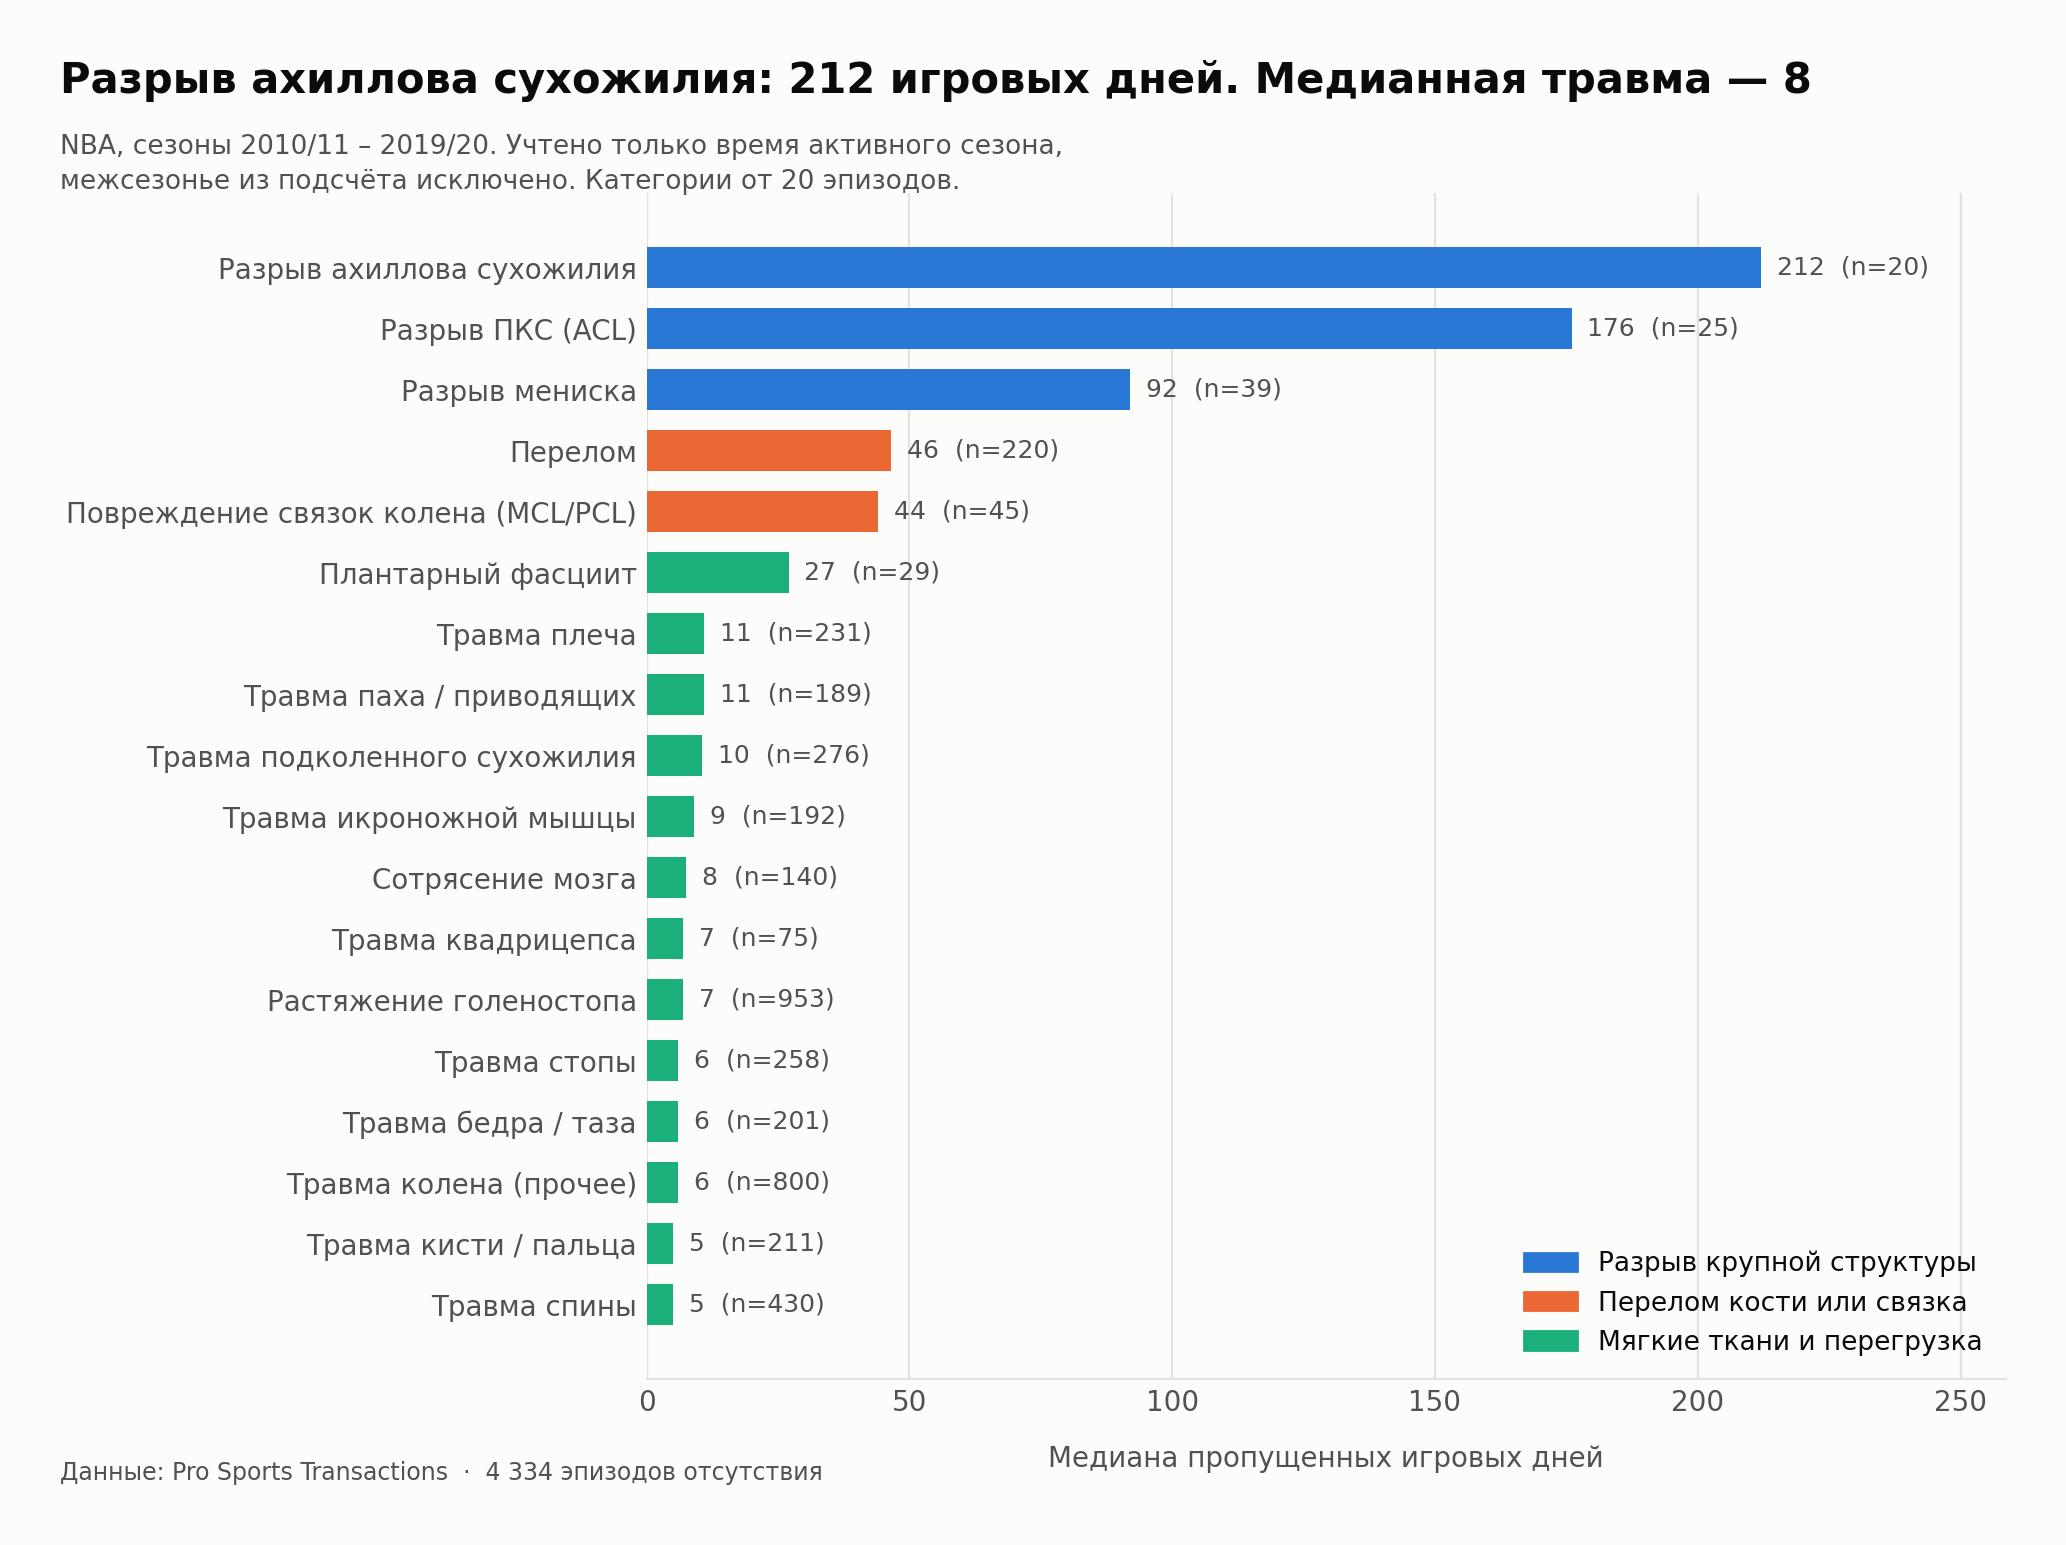

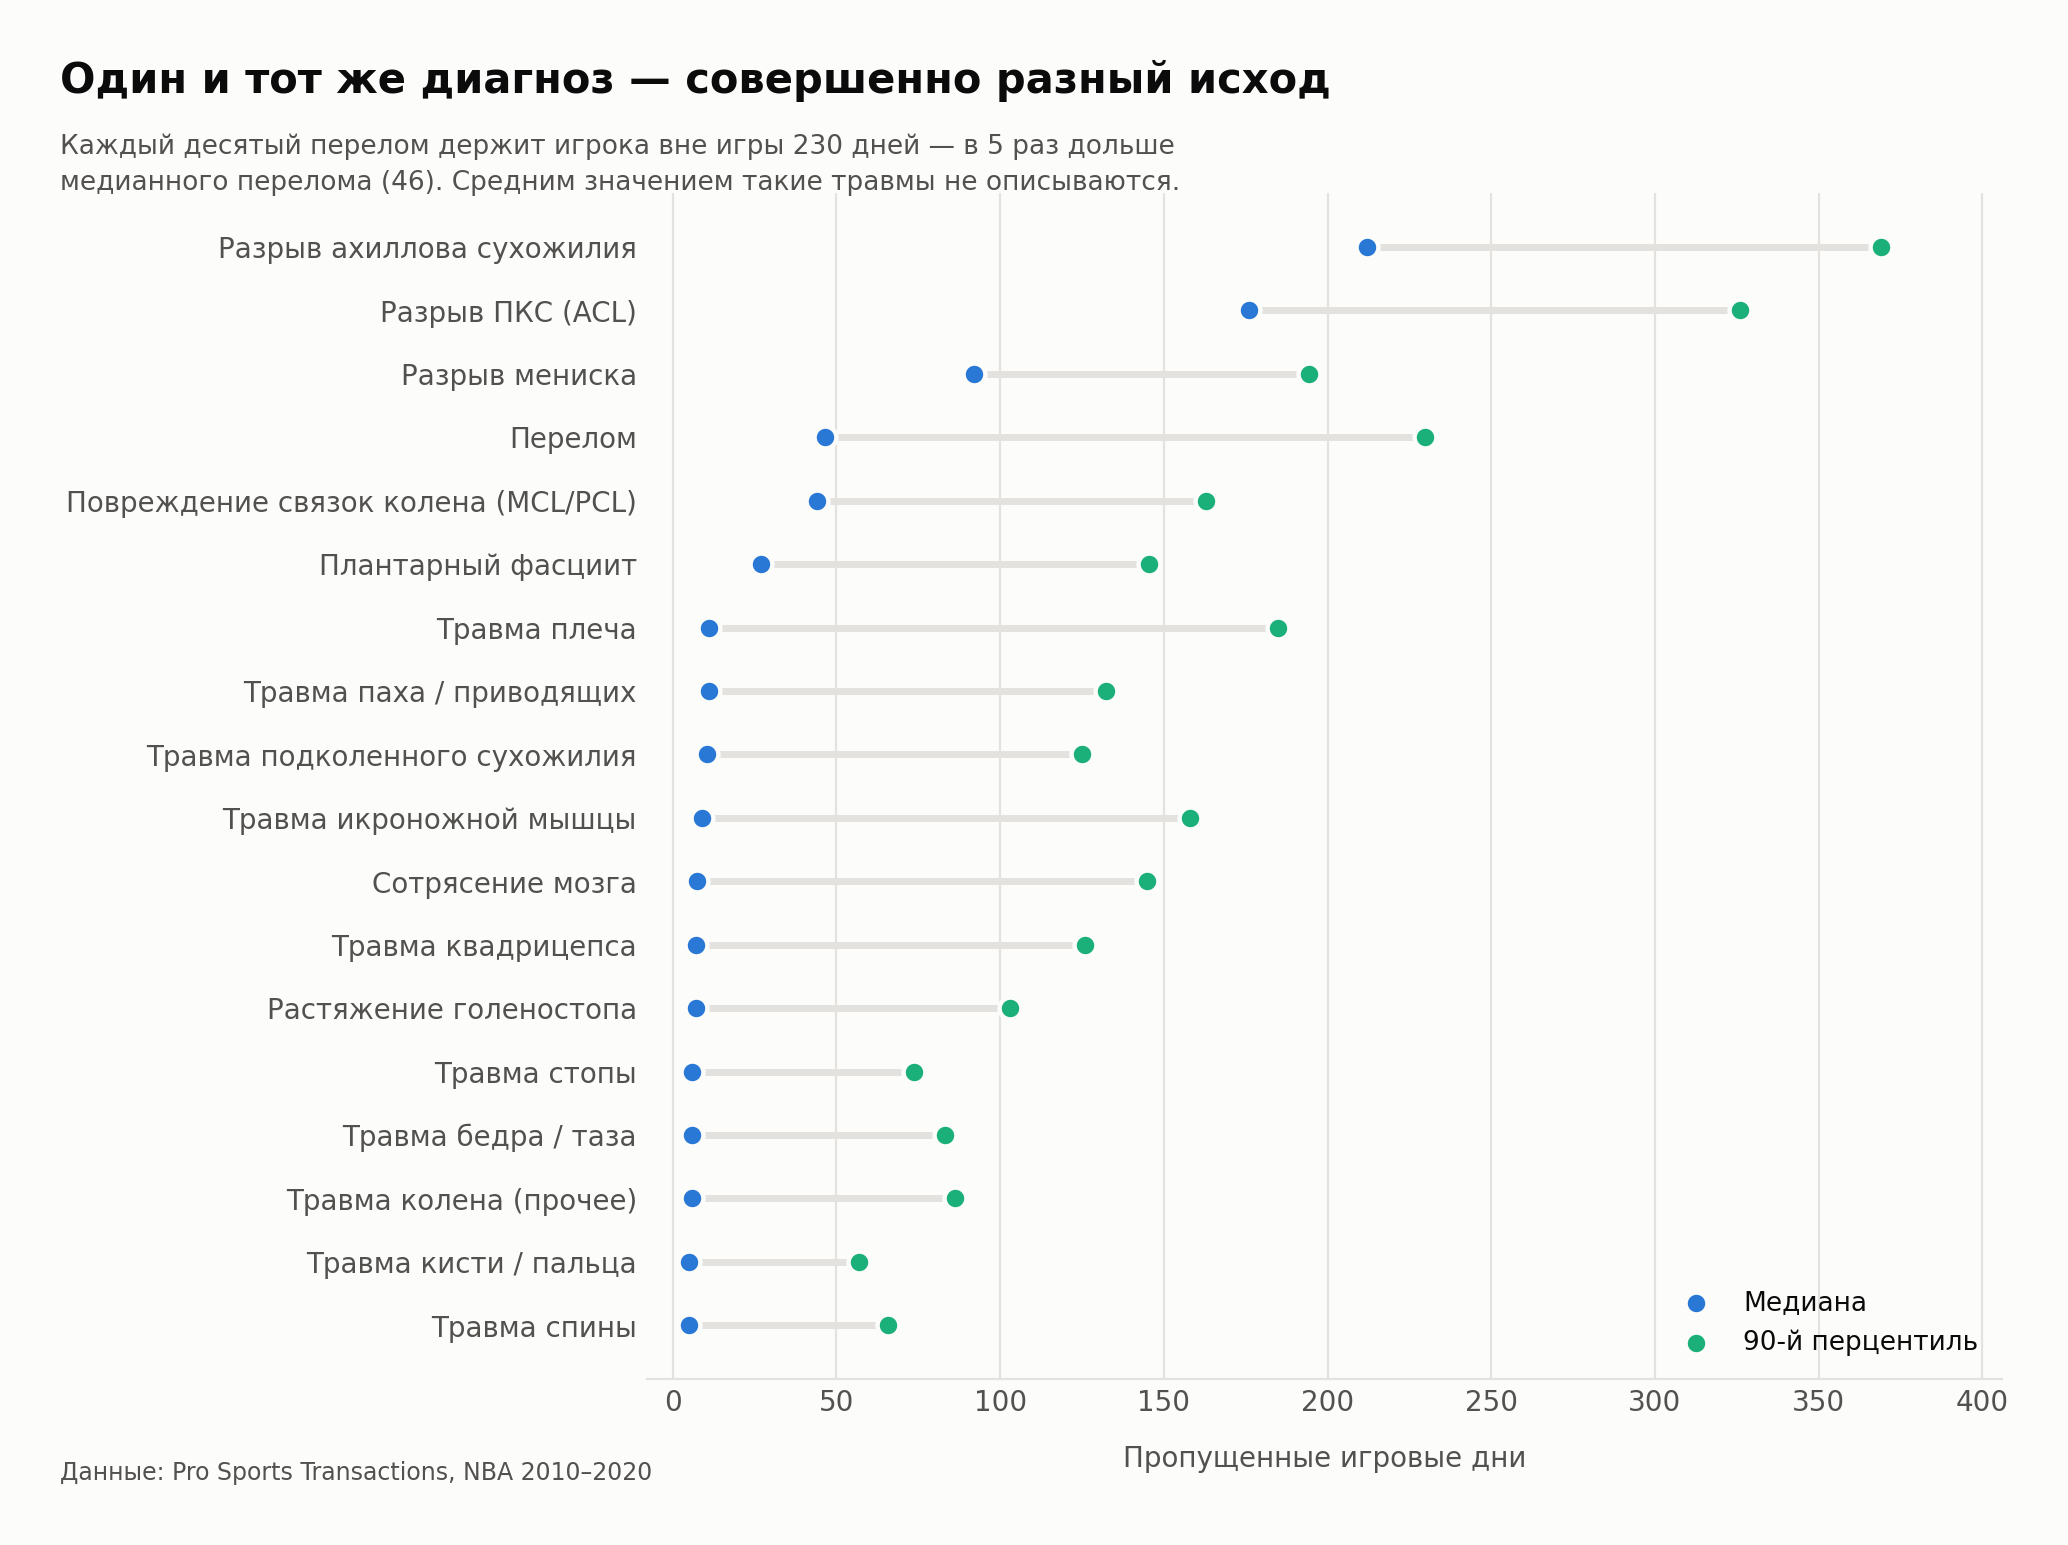

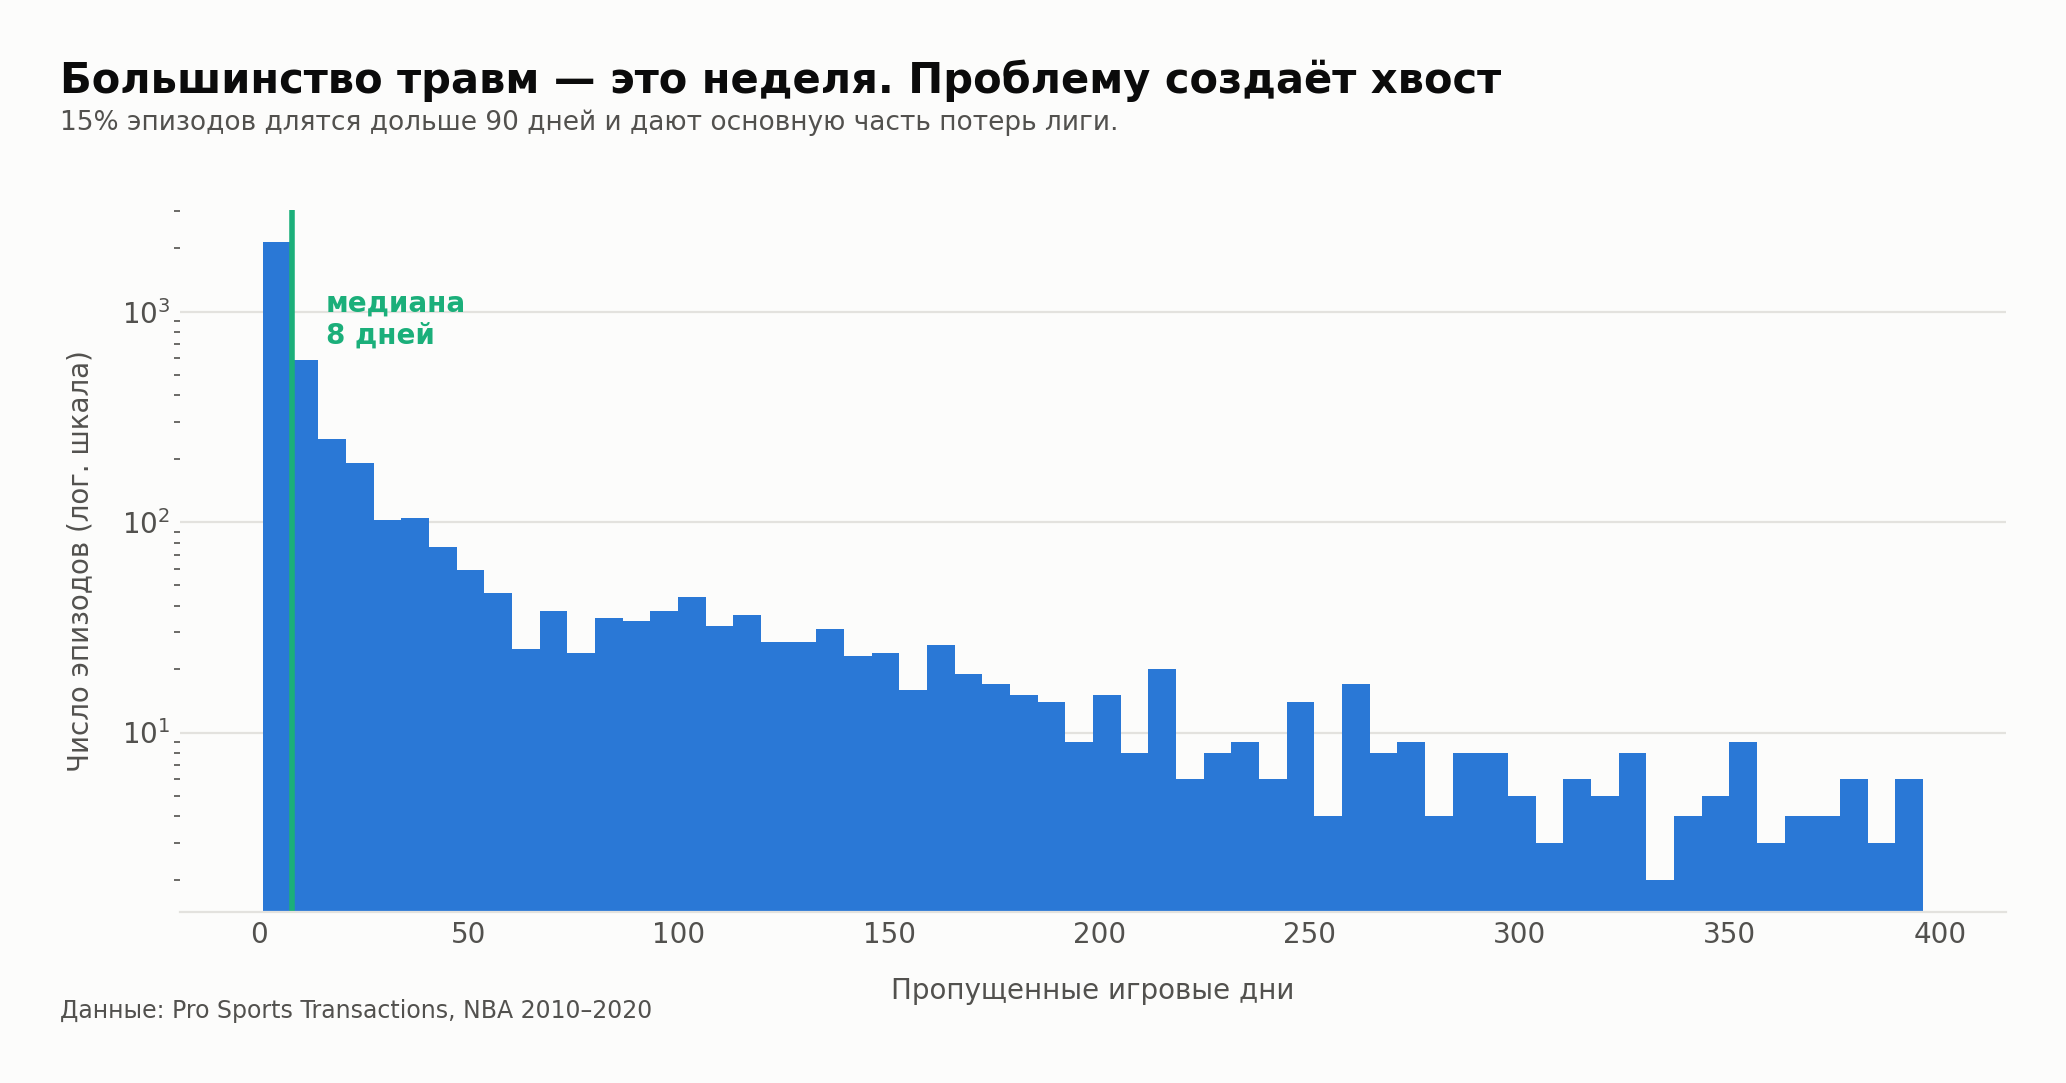

In [8]:
figures.median_by_injury(table, "01_median_days_by_injury.png",
                         overall_median, len(clean))
figures.spread_median_p90(table, "02_spread_median_p90.png")
figures.duration_distribution(ep, "03_duration_distribution.png")

from IPython.display import Image, display  # noqa: E402
for name in ("01_median_days_by_injury", "02_spread_median_p90",
             "03_duration_distribution"):
    display(Image(filename=f"{name}.png", width=900))

## Выводы

**1. Тяжесть идёт тремя ярусами, а не двумя.** Разрыв крупной структуры — ахиллово
сухожилие, ПКС, мениск — стоит 92–212 игровых дней. Перелом кости и повреждение связок
колена держатся на 44–46. Мягкие ткани и перегрузка укладываются в 5–27. Между первым
ярусом и вторым разрыв вдвое, между вторым и третьим — вчетверо.

Первая версия этого вывода делила травмы на два класса и была неверной: в категорию
связок колена попали растяжения, из-за чего ярус выглядел легче, чем он есть.

**2. Неопределённость живёт в лёгких травмах, а не в тяжёлых.** У разрыва ахилла среднее
совпадает с медианой: порвал — выбыл примерно на год, вариантов мало. У травмы
квадрицепса среднее в 5,7 раза выше медианы — обычно неделя, но каждый десятый случай
тянется четыре месяца. Чем легче диагноз, тем хуже по нему строится прогноз. Отношение
среднего к медиане падает с 5,7 у мягких тканей до 1,0 у структурных повреждений.

**3. Хвост решает всё.** 14,5% эпизодов длятся дольше 90 дней и дают основную часть
суммарных потерь лиги.

**4. Диагноз задаёт не срок, а диапазон.** У перелома медиана 46 дней, а 90-й
перцентиль — 230. Один и тот же диагноз разводит игроков на полгода разницы.
Прогноз «вернётся через месяц» по одному названию травмы не строится.

## Чего эти данные не говорят

Честный список ограничений — он же список того, что можно посчитать дальше.

- **Это не диагнозы.** Формулировки писали пресс-службы клубов, а не врачи. «Sore knee»
  может скрывать что угодно.
- **Дни, а не матчи.** Календарь игр сюда не подключён, поэтому «230 дней» — не то же
  самое, что «140 пропущенных матчей». Это следующий шаг.
- **Возвращение ≠ восстановление.** Данные фиксируют выход в состав, а не возврат
  к прежнему уровню игры. Чтобы измерить второе, нужна статистика результативности
  до и после.
- **Малые выборки.** У разрыва ахилла всего 20 эпизодов. Порядок величины надёжен,
  точное число — нет.
- **Тяжесть распознаётся по тексту и различается не везде.** Категория связок колена
  смешивает растяжения и разрывы, поэтому названа повреждением.
- **Окно сезона взято фиксированным** (15.10 – 15.06), хотя реальные даты плей-офф
  плавают. Погрешность в пределах пары недель на длинных эпизодах.

## Воспроизведение

```bash
pip install -r requirements.txt
jupyter lab analysis.ipynb
```

Данные: [Pro Sports Transactions](https://www.prosportstransactions.com/),
собраны через [gboogy/nba-injury-data-scraper](https://github.com/gboogy/nba-injury-data-scraper).
